In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Dict
from matplotlib.colors import to_rgb, to_hex
from matplotlib.patches import Patch
import os

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [3]:
# ----------------------------
# User inputs
# ----------------------------
INPUT_FILE = "graphpad_CSV_files/marker_proportion.csv"
OUTDIR = "plots"

# Markers to visualize
MARKERS = [
    "CD34+", "CD10+", "CD14+",
    "CD34+/CD10-CD7-/GMPs",  # Will be renamed toGMP-like
    "CD41+", "CD45+", "CD45RA+", "CD56+", "CD90+", "CD117+", "CD235a+", "EPCR+", "HLADR++"
]

# Rename mapping
MARKER_RENAME = {
    "CD34+/CD10-CD7-/GMPs": "GMP-like"
}

In [4]:
# ----------------------------
# Load and filter data
# ----------------------------
df = pd.read_csv(INPUT_FILE)

# Rename columns to match expected names
df = df.rename(columns={'SEC61': 'concentration', 'Proportion': 'proportion'})

# Filter for SEC61 experiments
df = df[df['Experiment'].str.contains('SEC61', case=False, na=False)].copy()

print(f"Loaded {len(df)} rows")

print(f"Columns: {list(df.columns)}")
print(f"\nMarkers in data: {df['Marker'].unique() if 'Marker' in df.columns else 'N/A'}")
print(f"\nExperiments: {df['Experiment'].unique()}")

Loaded 2250 rows
Columns: ['Experiment', 'Sample', 'Sample type', 'Media', 'concentration', 'Live', 'Marker', 'proportion']

Markers in data: ['CD7+' 'CD10+' 'CD14+' 'CD15+' 'CD16+' 'CD19+' 'CD34+'
 'CD34+/CD10-CD7-/GMPs' 'CD34+CD45RA-' 'CD34+CD45RA-/CD90+EPCR+' 'CD38+'
 'CD41+' 'CD45+' 'CD45RA+' 'CD49c+' 'CD49f+' 'CD56+' 'CD90+' 'CD117+'
 'CD123+' 'CD135+' 'CD184+' 'CD235a+' 'EPCR+' 'HLADR++']

Experiments: ['Sakurai+SEC61' 'SS+SR1+SEC61' 'SS+UM171+SEC61']


In [5]:
# Check the actual structure of the data
df.head(20)

,Experiment,Sample,Sample type,Media,concentration,Live,Marker,proportion
6925,Sakurai+SEC61,D01 Well - D01 WLSM.fcs,CB1,Sakurai + DFMO,No inhibitors,97.8,CD7+,0.031
6926,Sakurai+SEC61,D02 Well - D02 WLSM.fcs,CB1,Sakurai + DFMO,No inhibitors,99.1,CD7+,0.000
6927,Sakurai+SEC61,D03 Well - D03 WLSM.fcs,CB1,Sakurai + DFMO,No inhibitors,98.9,CD7+,0.011
6928,Sakurai+SEC61,F04 Well - F04 WLSM.fcs,CB1,Sakurai + SEC61,Vehicle_SEC61,95.4,CD7+,0.000
6929,Sakurai+SEC61,G04 Well - G04 WLSM.fcs,CB1,Sakurai + SEC61,Vehicle_SEC61,97.9,CD7+,0.000
6930,Sakurai+SEC61,H04 Well - H04 WLSM.fcs,CB1,Sakurai + SEC61,Vehicle_SEC61,98.6,CD7+,0.000
6931,Sakurai+SEC61,F01 Well - F01 WLSM.fcs,CB1,Sakurai + SEC61,1 ng/mL,98.7,CD7+,0.000
6932,Sakurai+SEC61,G01 Well - G01 WLSM.fcs,CB1,Sakurai + SEC61,1 ng/mL,99.0,CD7+,0.025
6933,Sakurai+SEC61,H01 Well - H01 WLSM.fcs,CB1,Sakurai + SEC61,1 ng/mL,99.2,CD7+,0.012
6934,Sakurai+SEC61,F02 Well - F02 WLSM.fcs,CB1,Sakurai + SEC61,10 ng/mL,96.9,CD7+,0.000


In [6]:
# ----------------------------
# Data preparation
# ----------------------------
# Assuming columns: Experiment, Marker, Sample type, concentration, technical_replicate, proportion
# Adjust based on actual column names

# Rename marker if needed
if 'Marker' in df.columns:
    df['Marker'] = df['Marker'].replace(MARKER_RENAME)

# Filter for selected markers
markers_to_plot = [MARKER_RENAME.get(m, m) for m in MARKERS]
df_filtered = df[df['Marker'].isin(markers_to_plot)].copy()

print(f"Filtered to {len(df_filtered)} rows with selected markers")
print(f"Markers present: {sorted(df_filtered['Marker'].unique())}")

Filtered to 1170 rows with selected markers
Markers present: ['CD10+', 'CD117+', 'CD14+', 'CD235a+', 'CD34+', 'CD41+', 'CD45+', 'CD45RA+', 'CD56+', 'CD90+', 'EPCR+', 'GMP-like', 'HLADR++']


In [7]:
# ----------------------------
# Plotting helper function
# ----------------------------

def plot_marker_subplot(
    ax,
    sub: pd.DataFrame,
    marker_name: str,
    *,
    conc_colors: Optional[Dict[str, str]] = None,
    gradient_start: str = "powderblue",
    gradient_end: str = "darkcyan",
    show_legend: bool = False,
):
    """
    Plot one marker in a single subplot:
      - bar height = mean across technical_replicates of proportion
        for each (biological_replicate, concentration)
      - dots = each technical_replicate proportion
      - x-axis: single tick per biological_replicate (centered over concentrations)
    """

    # ---- Aggregate bars ----
    gbar = (
        sub.groupby(["Sample type", "concentration"], as_index=False)
           .agg(mean_prop=("proportion", "mean"))
    )

    # ---- Ordering ----
    bio_order = sorted(sub["Sample type"].astype(str).unique())

    priority = ["No inhibitors", "Vehicle"]
    conc_in_data_order = (
        sub["concentration"]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )
    conc_unique = (
        [c for c in priority if c in conc_in_data_order] +
        [c for c in conc_in_data_order if c not in priority]
    )

    # ---- Build concentration color palette ----
    base_defaults = {"No inhibitors": "gainsboro", "Vehicle": "darkgrey"}
    user_map = {str(k): v for k, v in (conc_colors or {}).items()}

    final_colors: Dict[str, str] = dict(base_defaults)
    final_colors.update(user_map)

    remaining = [c for c in conc_unique if c not in final_colors]
    n = len(remaining)

    if n > 0:
        c0 = np.array(to_rgb(gradient_start))
        c1 = np.array(to_rgb(gradient_end))
        if n == 1:
            final_colors[remaining[0]] = to_hex(c0)
        else:
            for i, conc in enumerate(remaining):
                t = i / (n - 1)
                rgb = (1 - t) * c0 + t * c1
                final_colors[conc] = to_hex(rgb)

    def _c(conc: str) -> str:
        return final_colors.get(str(conc), "lightgrey")

    # ---- Layout params ----
    conc_w = 0.8
    gap_between_bios = 0.8

    # ---- Compute x positions ----
    x_positions = {}          # (bio, conc) -> x
    bio_centers = {}          # bio -> center x

    x = 0.0
    for b in bio_order:
        start_x = x
        for conc in conc_unique:
            x_positions[(b, conc)] = x
            x += 1.0
        end_x = x - 1.0
        bio_centers[b] = (start_x + end_x) / 2.0
        x += gap_between_bios

    # ---- Bars ----
    for _, row in gbar.iterrows():
        b = str(row["Sample type"])
        conc = str(row["concentration"])
        xpos = x_positions.get((b, conc))
        if xpos is None:
            continue
        ax.bar(
            xpos,
            row["mean_prop"],
            width=conc_w * 0.9,
            color=_c(conc),
            alpha=0.85,
            edgecolor="none",
        )

    # ---- Dots (technical replicates) ----
    rng = np.random.default_rng(0)
    for _, row in sub.iterrows():
        b = str(row["Sample type"])
        conc = str(row["concentration"])
        base_x = x_positions.get((b, conc))
        if base_x is None:
            continue
        jitter = rng.normal(0, conc_w * 0.08)
        ax.scatter(
            base_x + jitter,
            row["proportion"],
            s=25,
            alpha=0.75,
            zorder=3,
            color='black',
            edgecolors="none",
        )

    # ---- X-axis ----
    ax.set_xticks([bio_centers[b] for b in bio_order])
    ax.set_xticklabels(bio_order, fontsize=8)
    
    # ---- Y-axis and title ----
    ax.set_ylabel("% Positive", fontsize=8)
    ax.set_title(marker_name, fontsize=9, fontweight='bold')
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis='both', which='major', labelsize=8)

    # ---- Legend (if requested) ----
    if show_legend:
        legend_handles = [
            Patch(facecolor=_c(conc), edgecolor="none", label=conc)
            for conc in conc_unique
        ]
        ax.legend(
            handles=legend_handles,
            title="Concentration",
            frameon=False,
            fontsize=7,
            title_fontsize=8,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )

    # Add box around subplot
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

    return conc_unique

Creating grid: 3 experiments x 13 markers

Saved comprehensive grid to plots/all_markers_grid.pdf


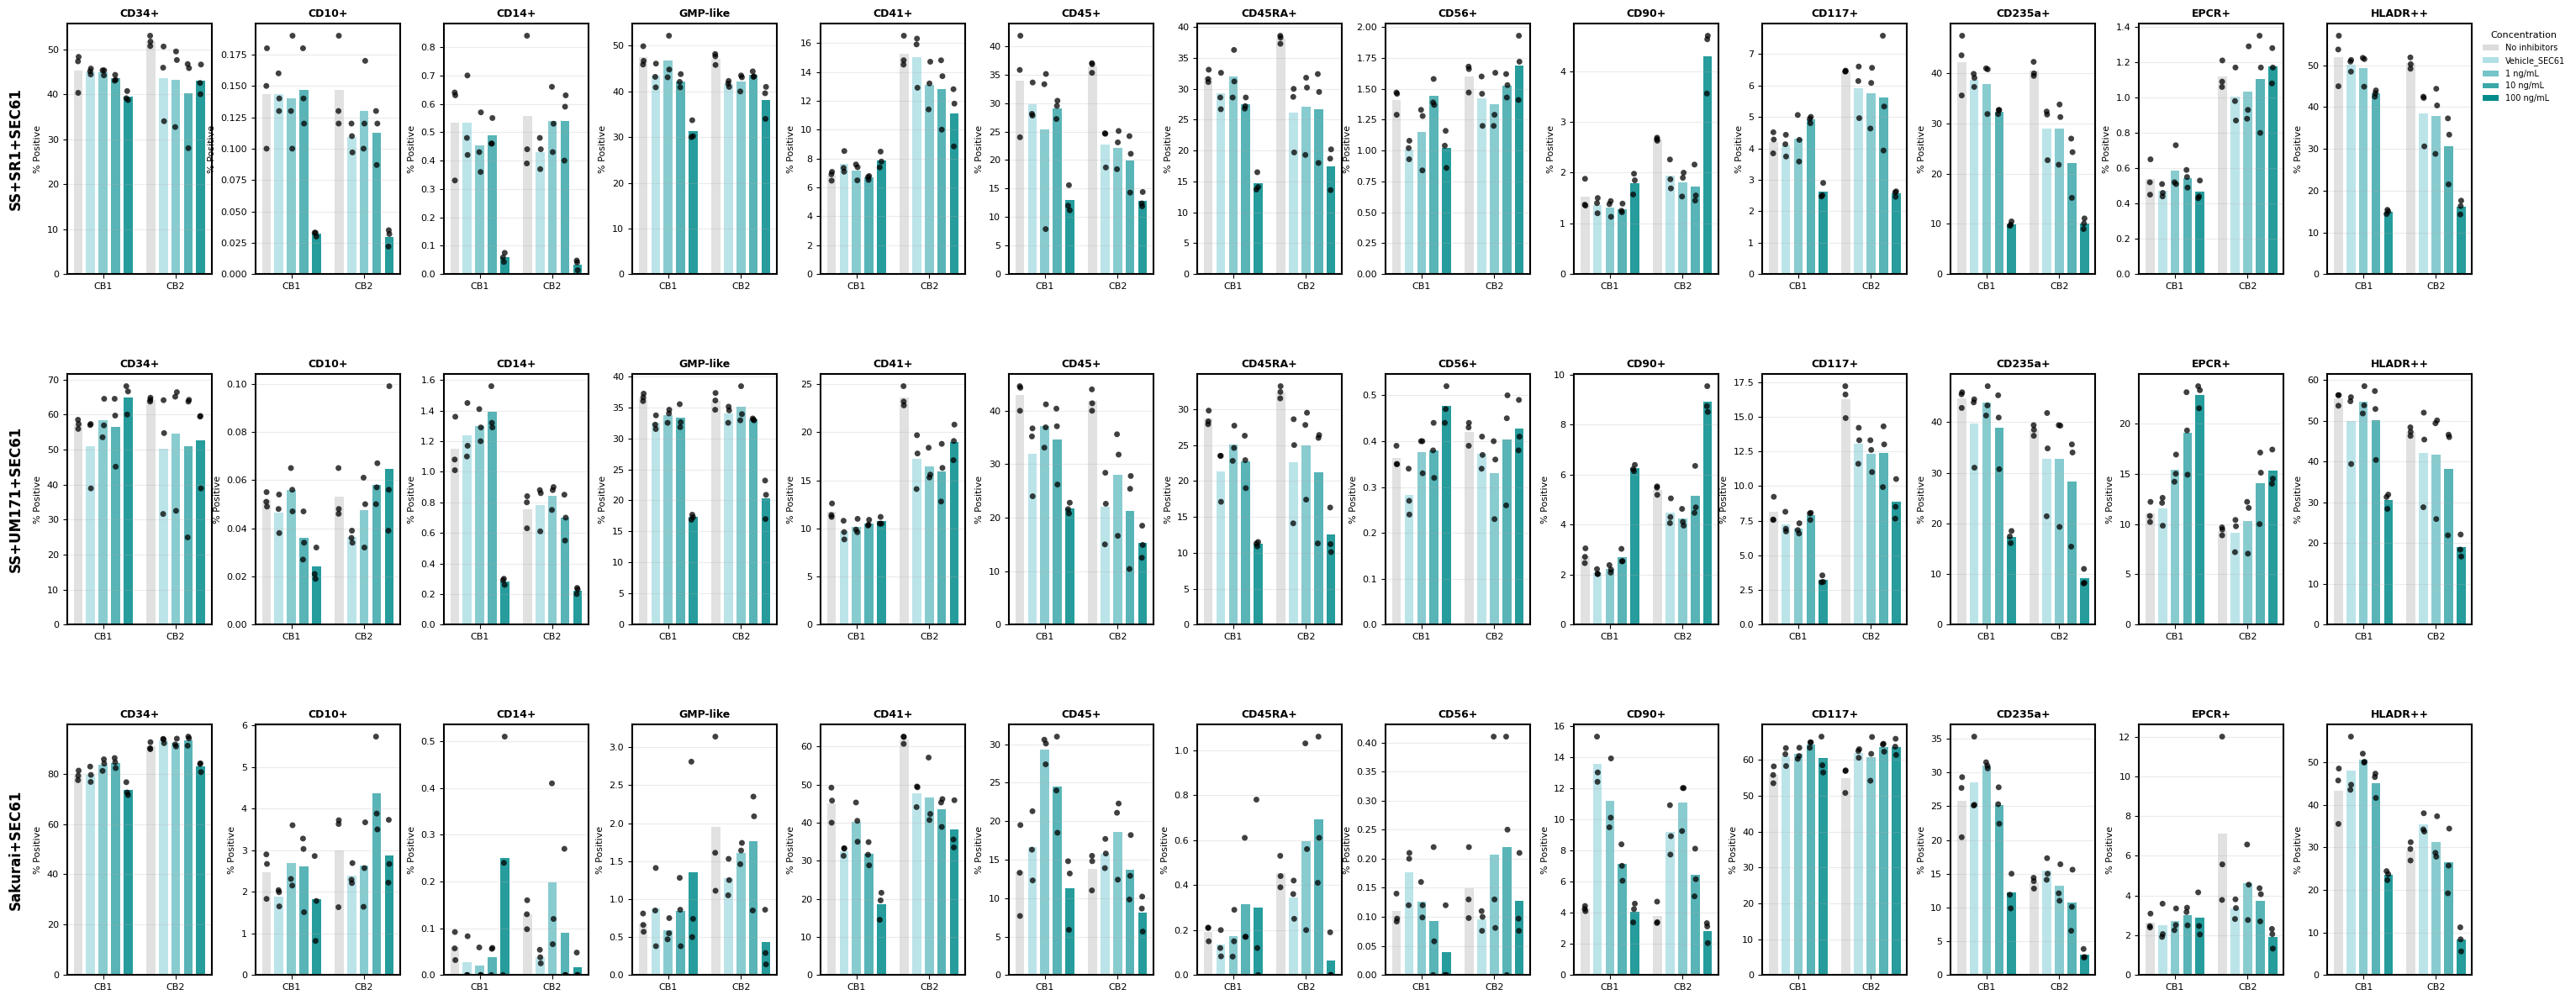

In [8]:
# ----------------------------
# Create comprehensive grid plot
# ----------------------------
os.makedirs(OUTDIR, exist_ok=True)

# Get unique experiments
experiments = sorted(df_filtered['Experiment'].unique())
n_experiments = len(experiments)
n_markers = len(markers_to_plot)

print(f"Creating grid: {n_experiments} experiments x {n_markers} markers")

# Create figure with subplots
fig_width = max(20, n_markers * 2.5)
fig_height = max(12, n_experiments * 3)
fig, axes = plt.subplots(
    n_experiments, n_markers,
    figsize=(fig_width, fig_height),
    squeeze=False
)

# Track concentrations for legend
all_conc = None

# Plot each experiment x marker combination
for exp_idx, experiment in enumerate(experiments):
    exp_data = df_filtered[df_filtered['Experiment'] == experiment]
    
    for marker_idx, marker in enumerate(markers_to_plot):
        ax = axes[exp_idx, marker_idx]
        marker_data = exp_data[exp_data['Marker'] == marker]
        
        if len(marker_data) > 0:
            # Show legend only on the first plot of first row
            show_legend = (exp_idx == 0 and marker_idx == n_markers - 1)
            conc_unique = plot_marker_subplot(
                ax, marker_data, marker,
                show_legend=show_legend
            )
            if all_conc is None:
                all_conc = conc_unique
        else:
            # No data for this marker in this experiment
            ax.text(0.5, 0.5, 'No data', 
                   ha='center', va='center', 
                   transform=ax.transAxes,
                   fontsize=10, color='gray')
            ax.set_title(marker, fontsize=9, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor('black')
                spine.set_linewidth(1.5)
    
    # Add experiment name as row label on the left
    axes[exp_idx, 0].text(
        -0.3, 0.5, experiment,
        transform=axes[exp_idx, 0].transAxes,
        fontsize=12, fontweight='bold',
        rotation=90, va='center', ha='right'
    )

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(left=0.08, hspace=0.4, wspace=0.3)

# Save
outpath = os.path.join(OUTDIR, "all_markers_grid.pdf")
fig.savefig(outpath, dpi=300, bbox_inches="tight")
print(f"\nSaved comprehensive grid to {outpath}")

plt.show()
plt.close(fig)


Creating grid (transposed): 13 markers x 3 experiments

Saved comprehensive grid to plots/all_markers_grid_transposed.pdf


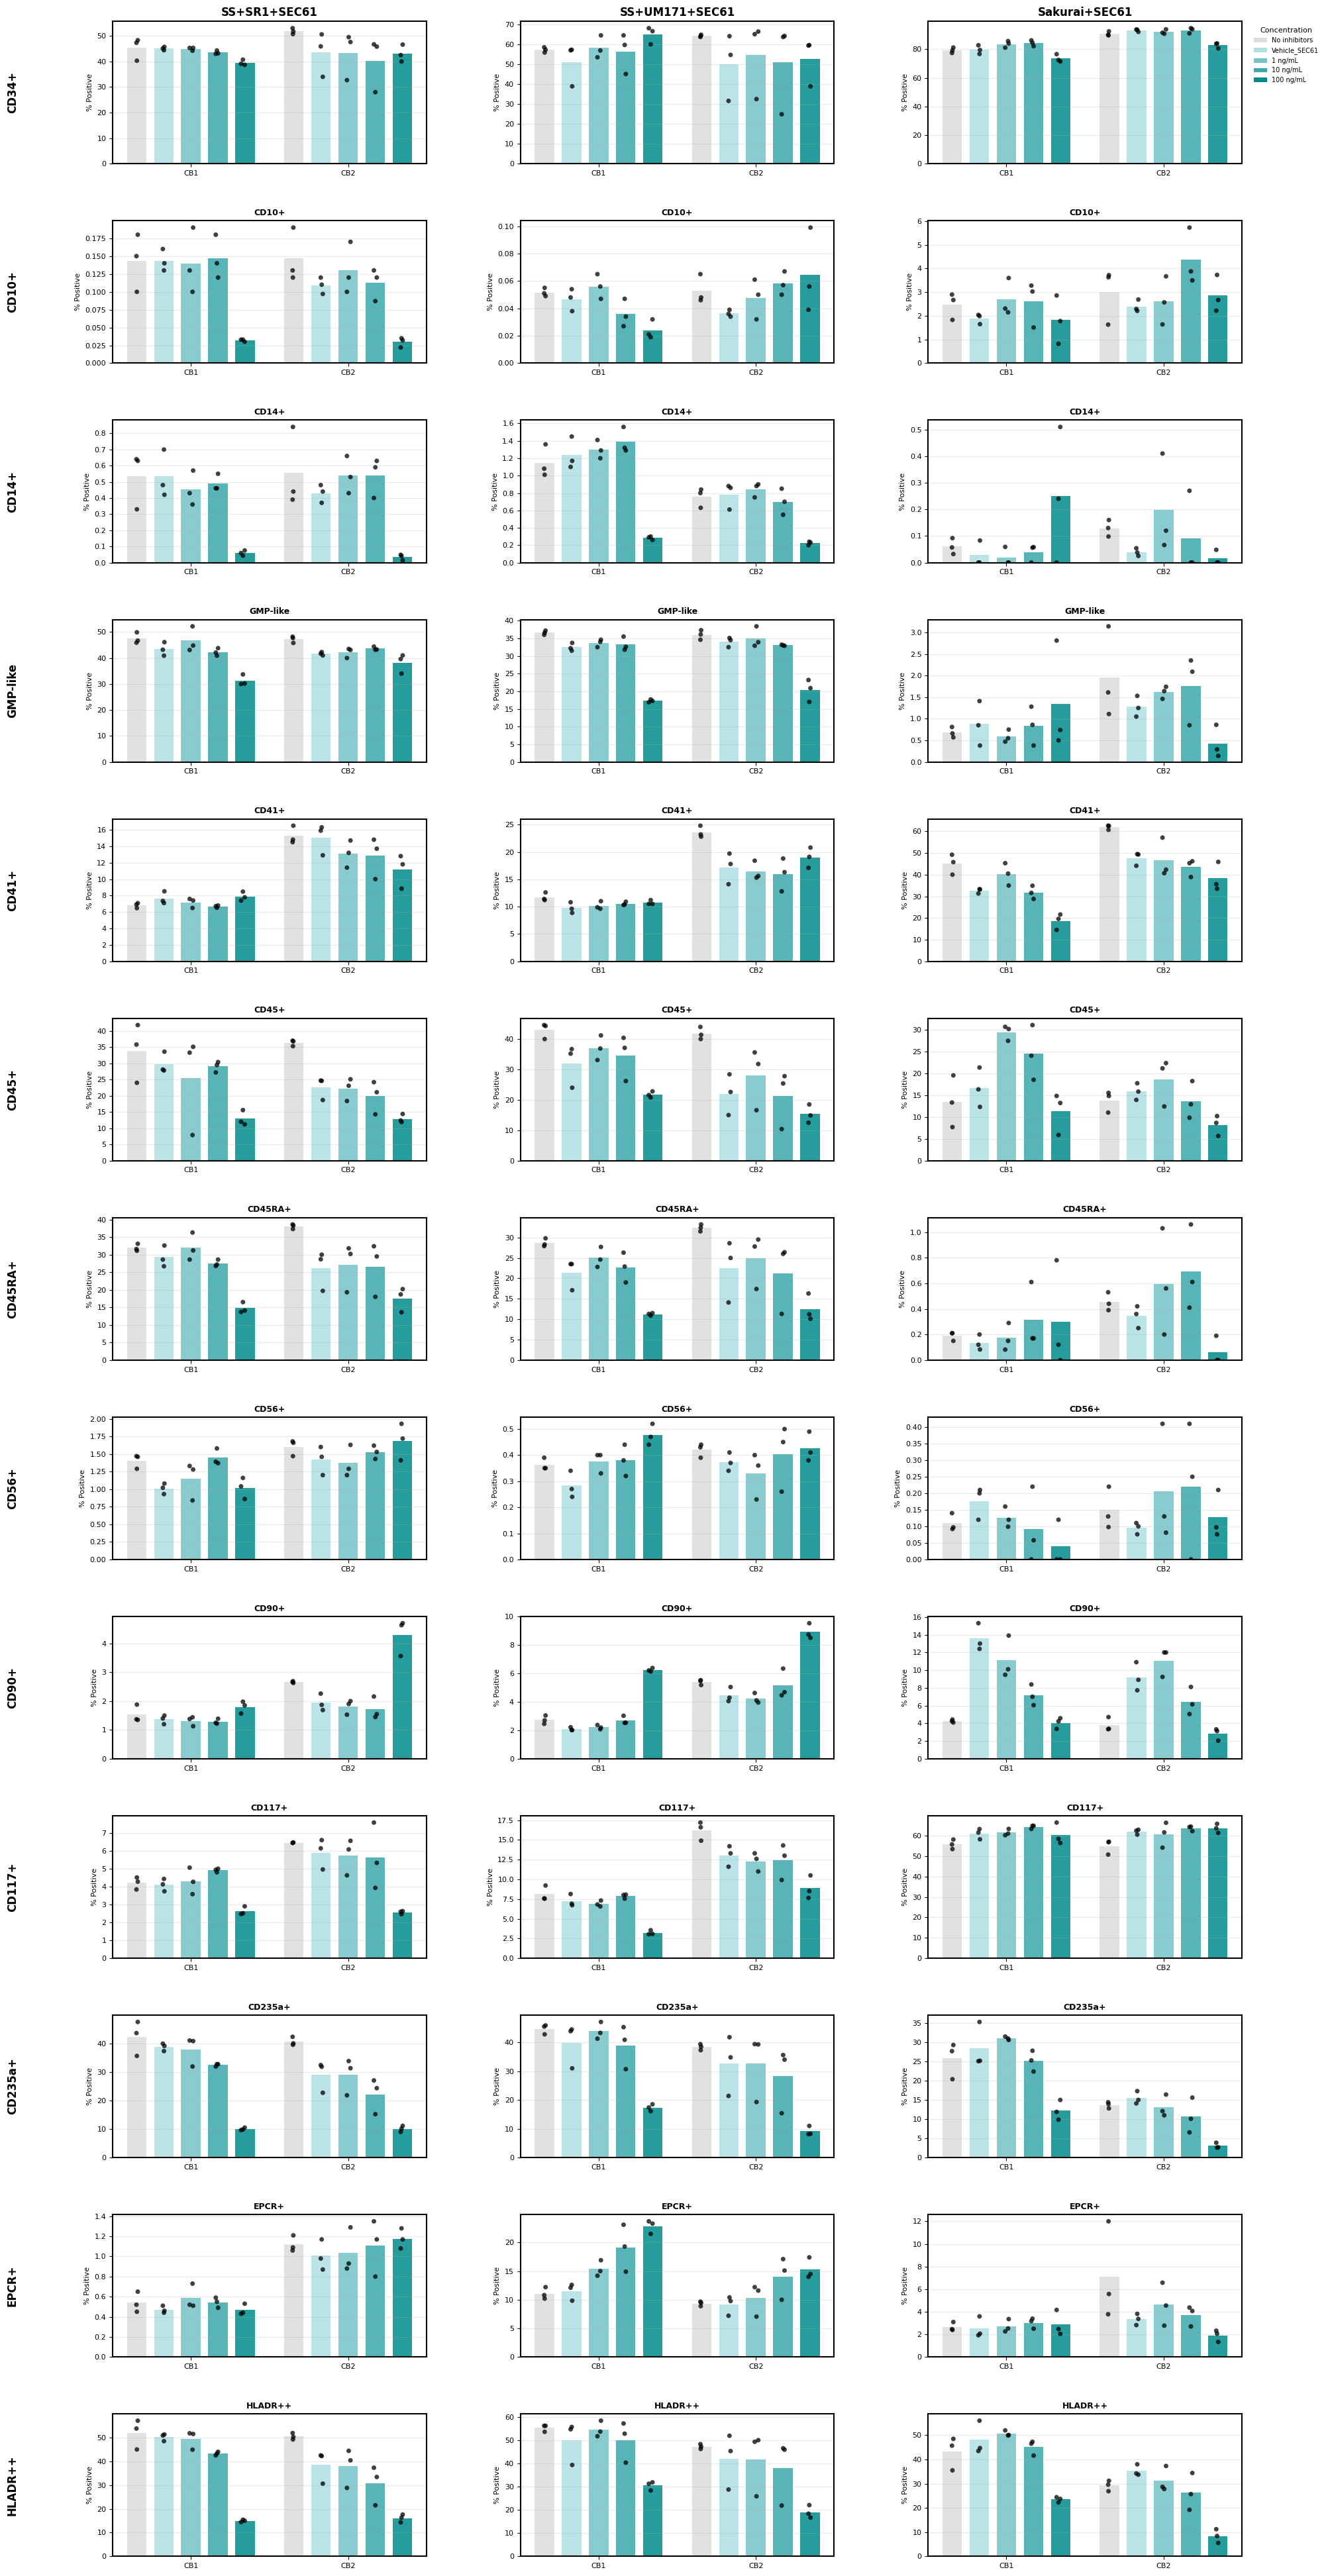

In [9]:
# ----------------------------
# Create comprehensive grid plot (TRANSPOSED: experiments as columns)
# ----------------------------
os.makedirs(OUTDIR, exist_ok=True)

# Get unique experiments
experiments = sorted(df_filtered['Experiment'].unique())
n_experiments = len(experiments)
n_markers = len(markers_to_plot)

print(f"Creating grid (transposed): {n_markers} markers x {n_experiments} experiments")

# Create figure with subplots (ROWS=markers, COLS=experiments)
fig_width = max(20, n_experiments * 2.5)
fig_height = max(12, n_markers * 3)
fig, axes = plt.subplots(
    n_markers, n_experiments,
    figsize=(fig_width, fig_height),
    squeeze=False
)

# Track concentrations for legend
all_conc = None

# Plot each marker x experiment combination
for marker_idx, marker in enumerate(markers_to_plot):
    for exp_idx, experiment in enumerate(experiments):
        ax = axes[marker_idx, exp_idx]

        exp_data = df_filtered[df_filtered['Experiment'] == experiment]
        marker_data = exp_data[exp_data['Marker'] == marker]

        if len(marker_data) > 0:
            # Show legend only on the top-right subplot
            show_legend = (marker_idx == 0 and exp_idx == n_experiments - 1)
            conc_unique = plot_marker_subplot(
                ax, marker_data, marker,
                show_legend=show_legend
            )
            if all_conc is None:
                all_conc = conc_unique
        else:
            # No data for this marker in this experiment
            ax.text(
                0.5, 0.5, 'No data',
                ha='center', va='center',
                transform=ax.transAxes,
                fontsize=10, color='gray'
            )
            ax.set_title(marker, fontsize=9, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor('black')
                spine.set_linewidth(1.5)

        # Column headers = experiment names (top row only)
        if marker_idx == 0:
            ax.set_title(str(experiment), fontsize=12, fontweight='bold')

    # Row label on the left for each marker (first column only)
    axes[marker_idx, 0].text(
        -0.3, 0.5, marker,
        transform=axes[marker_idx, 0].transAxes,
        fontsize=12, fontweight='bold',
        rotation=90, va='center', ha='right'
    )

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(left=0.08, hspace=0.4, wspace=0.3)

# Save
outpath = os.path.join(OUTDIR, "all_markers_grid_transposed.pdf")
fig.savefig(outpath, dpi=300, bbox_inches="tight")
print(f"\nSaved comprehensive grid to {outpath}")

plt.show()
plt.close(fig)
